In [1]:
## Q2.
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# User input for image resolution
px = 200
img_size = (px,px)
imgs = 100000

In [3]:
class MultiLabelImageDatasetBinary(torch.utils.data.Dataset):
    """
    CSV format:
      - one column contains image filename/path (default 'Image Number' or set path_col)
      - other columns are label columns containing 0/1 or values like 'yes','no','True','False'
    Returns: (image_tensor, multi_hot_tensor)
    """
    def __init__(self, csv_file, img_dir=None, transform=None, path_col='Image Number', label_cols=None):
        self.df = pd.read_csv(csv_file, dtype=str, nrows=imgs)
        self.img_dir = img_dir
        self.transform = transform
        self.path_col = path_col

        # infer label columns if not provided: all columns except path_col
        if label_cols is None:
            label_cols = [c for c in self.df.columns if c != self.path_col]
        self.label_cols = label_cols

        # normalize label values to 0/1
        def to_binary(x):
            if pd.isna(x): 
                return 0
            s = str(x).strip().lower()
            if s in ('1','true','t','yes','y','on'):
                return 1
            if s in ('0','false','f','no','n','off'):
                return 0
            # try numeric
            try:
                return 1 if float(s) != 0 else 0
            except:
                return 0

        labels_array = self.df[self.label_cols].applymap(to_binary).astype(np.int64).values
        self.labels = labels_array  # shape (N, n_labels)

        # file paths
        self.paths = self.df[self.path_col].astype(str).tolist()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx] + '.jpg'
        if self.img_dir:
            p = os.path.join(self.img_dir, p)
        img = Image.open(p).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.from_numpy(self.labels[idx].astype(np.float32))
        return img, label

# Replace ImageFolder usage and plotting setup
csv_file = './image_labels.csv'     # <-- set this to your CSV
img_base_dir = './dataset'     # optional, set to None if CSV contains full paths
path_col = 'Image Number'                 # update if different

batch_size = 25
load_image = transforms.Compose([
    transforms.Resize((px, px)),
    transforms.ToTensor(),
])

dataset = MultiLabelImageDatasetBinary(csv_file, img_dir=img_base_dir, transform=load_image, path_col=path_col)
print("Number of classes:", len(dataset.label_cols))
print("Class names:", dataset.label_cols)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
data_iter = iter(dataloader)
# get a batch
images, labels = next(iter(dataloader))   # images: (B,C,H,W), labels: (B,n_classes)

# small helper to build readable titles for plotting
def labels_to_title(label_row, label_names):
    idxs = [label_names[i] for i,v in enumerate(label_row) if v]
    return ",".join(idxs) if idxs else "none"

label_names = dataset.label_cols

/tmp/ipykernel_1610224/167526225.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  labels_array = self.df[self.label_cols].applymap(to_binary).astype(np.int64).values


Number of classes: 10
Class names: ['Goal', 'Start/Restart', 'Joy', 'Yellow Card', 'Red Card', 'Ball', 'Stadium View', 'Referee', 'Penalty Kick', 'Free Kick']


In [4]:
# Visualize data 

# Define function that plots multiple images in an array of images
def PlotImages(ix_start,num_img,rows,cols,images,labels,label_names,color=True):
    plt.figure(figsize=(10,10))
    plt.subplots_adjust(wspace=0.5,hspace=0.5)
    for i in range(num_img):
        plt.subplot(rows,cols,i+1)
        plt.axis('off')
        if color:
            plt.imshow(images.permute(0, 2, 3, 1)[ix_start+i])
        else: 
            plt.imshow(np.squeeze(images[ix_start+i]),cmap='Greys')
        plt.title(labels_to_title(labels[i].numpy(), label_names))

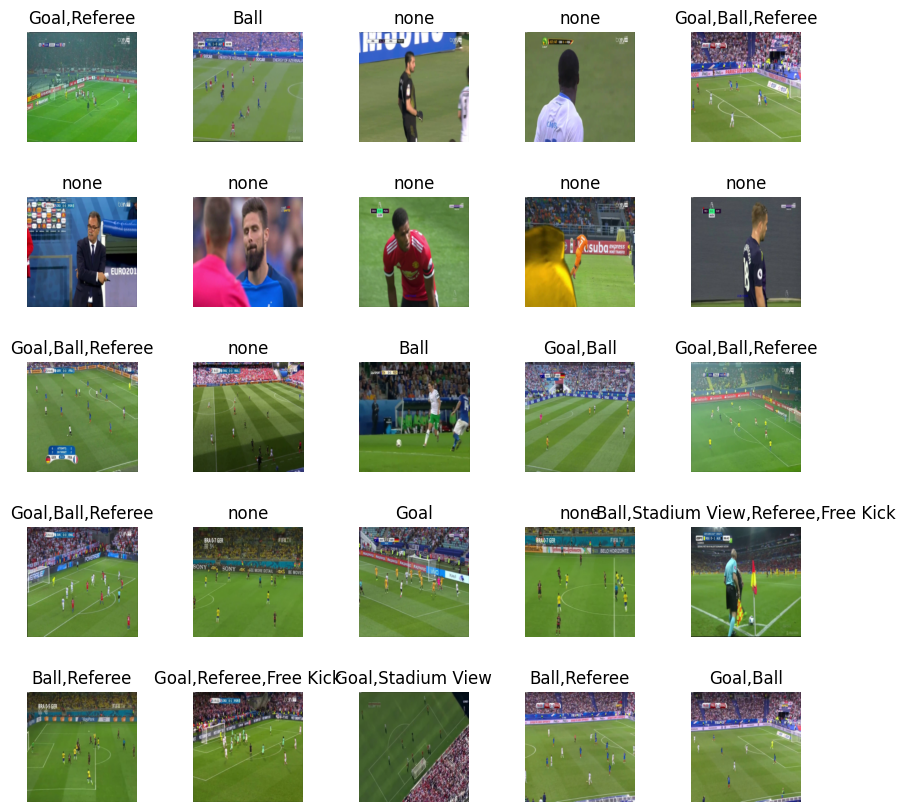

In [5]:
images, labels = next(data_iter)
next(data_iter)
PlotImages(0,batch_size,5,5,images,labels,label_names,color=True)

/tmp/ipykernel_1610224/167526225.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  labels_array = self.df[self.label_cols].applymap(to_binary).astype(np.int64).values
/tmp/ipykernel_1610224/167526225.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  labels_array = self.df[self.label_cols].applymap(to_binary).astype(np.int64).values
/tmp/ipykernel_1610224/167526225.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  labels_array = self.df[self.label_cols].applymap(to_binary).astype(np.int64).values


Dataset size: 100000, train 80000, val 20000, classes: 10
Class names: ['Goal', 'Start/Restart', 'Joy', 'Yellow Card', 'Red Card', 'Ball', 'Stadium View', 'Referee', 'Penalty Kick', 'Free Kick']


/tmp/ipykernel_1610224/756795158.py:56: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=='cuda'))
/tmp/ipykernel_1610224/756795158.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Epoch 1/10  train_loss=0.1436  val_loss=0.1199  micro_f1=0.7488  hamming=0.0571


/tmp/ipykernel_1610224/756795158.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


...

Epoch 8/10  train_loss=0.0942  val_loss=0.0925  micro_f1=0.8107  hamming=0.0430


/tmp/ipykernel_1610224/756795158.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Epoch 9/10  train_loss=0.0927  val_loss=0.0905  micro_f1=0.8247  hamming=0.0414


/tmp/ipykernel_1610224/756795158.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Epoch 10/10  train_loss=0.0898  val_loss=0.0897  micro_f1=0.8214  hamming=0.0409
Training finished. Elapsed (min): 43.91  Best val micro-F1: 0.82467683584742


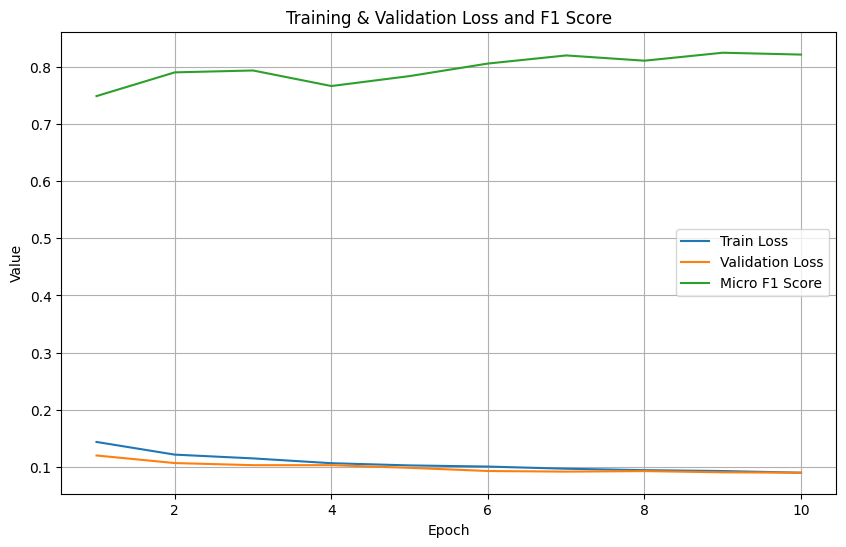

In [6]:
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, hamming_loss
from time import time

def train_multilabel_resnet(csv_file, img_base_dir, path_col, imgs,
                            px=200, batch_size=32, epochs=8, lr=1e-4,
                            device='cuda:0', val_frac=0.2, threshold=0.5):
    device = torch.device(device if torch.cuda.is_available() else 'cpu')

    # transforms
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop((px, px)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    val_transform = transforms.Compose([
        transforms.Resize((px, px)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])

    # dataset objects (read same CSV but different transforms)
    ds_full = MultiLabelImageDatasetBinary(csv_file, img_dir=img_base_dir, transform=val_transform, path_col=path_col)
    n = len(ds_full)
    val_n = int(n * val_frac)
    train_n = n - val_n
    indices = list(range(n))
    train_idx, val_idx = train_test_split(indices, test_size=val_frac, random_state=0, shuffle=True)

    # create two dataset instances so we can apply different transforms
    ds_train = MultiLabelImageDatasetBinary(csv_file, img_dir=img_base_dir, transform=train_transform, path_col=path_col)
    ds_val   = MultiLabelImageDatasetBinary(csv_file, img_dir=img_base_dir, transform=val_transform, path_col=path_col)

    train_set = torch.utils.data.Subset(ds_train, train_idx)
    val_set   = torch.utils.data.Subset(ds_val, val_idx)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    n_classes = len(ds_full.label_cols)
    print(f"Dataset size: {n}, train {len(train_set)}, val {len(val_set)}, classes: {n_classes}")
    print("Class names:", ds_full.label_cols)

    # model: ResNet50 backbone with new fc -> n_classes
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    in_feat = model.fc.in_features
    model.fc = nn.Linear(in_feat, n_classes)
    model = model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type=='cuda'))

    best_val_f1 = 0.0
    start = time()

    train_losses, val_losses, f1_scores = [], [], []

    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                logits = model(imgs)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * imgs.size(0)
        scheduler.step()

        # validation
        model.eval()
        val_loss = 0.0
        all_true = []
        all_pred = []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)
                logits = model(imgs)
                loss = criterion(logits, labels)
                val_loss += loss.item() * imgs.size(0)
                probs = torch.sigmoid(logits).cpu().numpy()
                preds = (probs >= threshold).astype(int)
                all_pred.append(preds)
                all_true.append(labels.cpu().numpy().astype(int))
        all_pred = np.vstack(all_pred)
        all_true = np.vstack(all_true)
        val_loss = val_loss / len(val_set)
        epoch_train_loss = running_loss / len(train_set)
        micro_f1 = f1_score(all_true, all_pred, average='micro', zero_division=0)
        ham_loss = hamming_loss(all_true, all_pred)
        train_losses.append(epoch_train_loss)
        val_losses.append(val_loss)
        f1_scores.append(micro_f1)


        print(f"Epoch {epoch}/{epochs}  train_loss={epoch_train_loss:.4f}  val_loss={val_loss:.4f}  micro_f1={micro_f1:.4f}  hamming={ham_loss:.4f}")

        # save best
        if micro_f1 > best_val_f1:
            best_val_f1 = micro_f1
            torch.save({
                'model_state_dict': model.state_dict(),
                'label_cols': ds_full.label_cols
            }, 'best_resnet50_multilabel.pth')

    elapsed = time() - start
    print("Training finished. Elapsed (min):", round(elapsed/60,2), " Best val micro-F1:", best_val_f1)

    # --- Plot training metrics ---
    epochs_range = range(1, epochs + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, val_losses, label='Validation Loss')
    plt.plot(epochs_range, f1_scores, label='Micro F1 Score')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title('Training & Validation Loss and F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, ds_full.label_cols

# Example usage (adjust CSV path and image dir):
model, class_names = train_multilabel_resnet(csv_file='./image_labels.csv',
                                             img_base_dir='./dataset',
                                             path_col='Image Number',
                                             imgs=imgs, px=200, batch_size=32, epochs=10,
                                             device='cuda:0', val_frac=0.2, threshold=0.5)
# ...existing code...

/tmp/ipykernel_1610224/167526225.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  labels_array = self.df[self.label_cols].applymap(to_binary).astype(np.int64).values


Goal: accuracy=95.64%  (positives=4804/20000)
Start/Restart: accuracy=99.86%  (positives=104/20000)
Joy: accuracy=99.07%  (positives=261/20000)
Yellow Card: accuracy=99.78%  (positives=113/20000)
Red Card: accuracy=99.94%  (positives=14/20000)
Ball: accuracy=83.90%  (positives=9611/20000)
Stadium View: accuracy=98.12%  (positives=844/20000)
Referee: accuracy=84.68%  (positives=7053/20000)
Penalty Kick: accuracy=99.83%  (positives=109/20000)
Free Kick: accuracy=98.27%  (positives=550/20000)
               precision    recall  f1-score   support

         Goal     0.8711    0.9609    0.9138      4804
Start/Restart     0.8378    0.8942    0.8651       104
          Joy     0.7219    0.4674    0.5674       261
  Yellow Card     0.8864    0.6903    0.7761       113
     Red Card     1.0000    0.1429    0.2500        14
         Ball     0.8820    0.7677    0.8209      9611
 Stadium View     0.7875    0.7595    0.7732       844
      Referee     0.7942    0.7634    0.7785      7053
 Penalty 

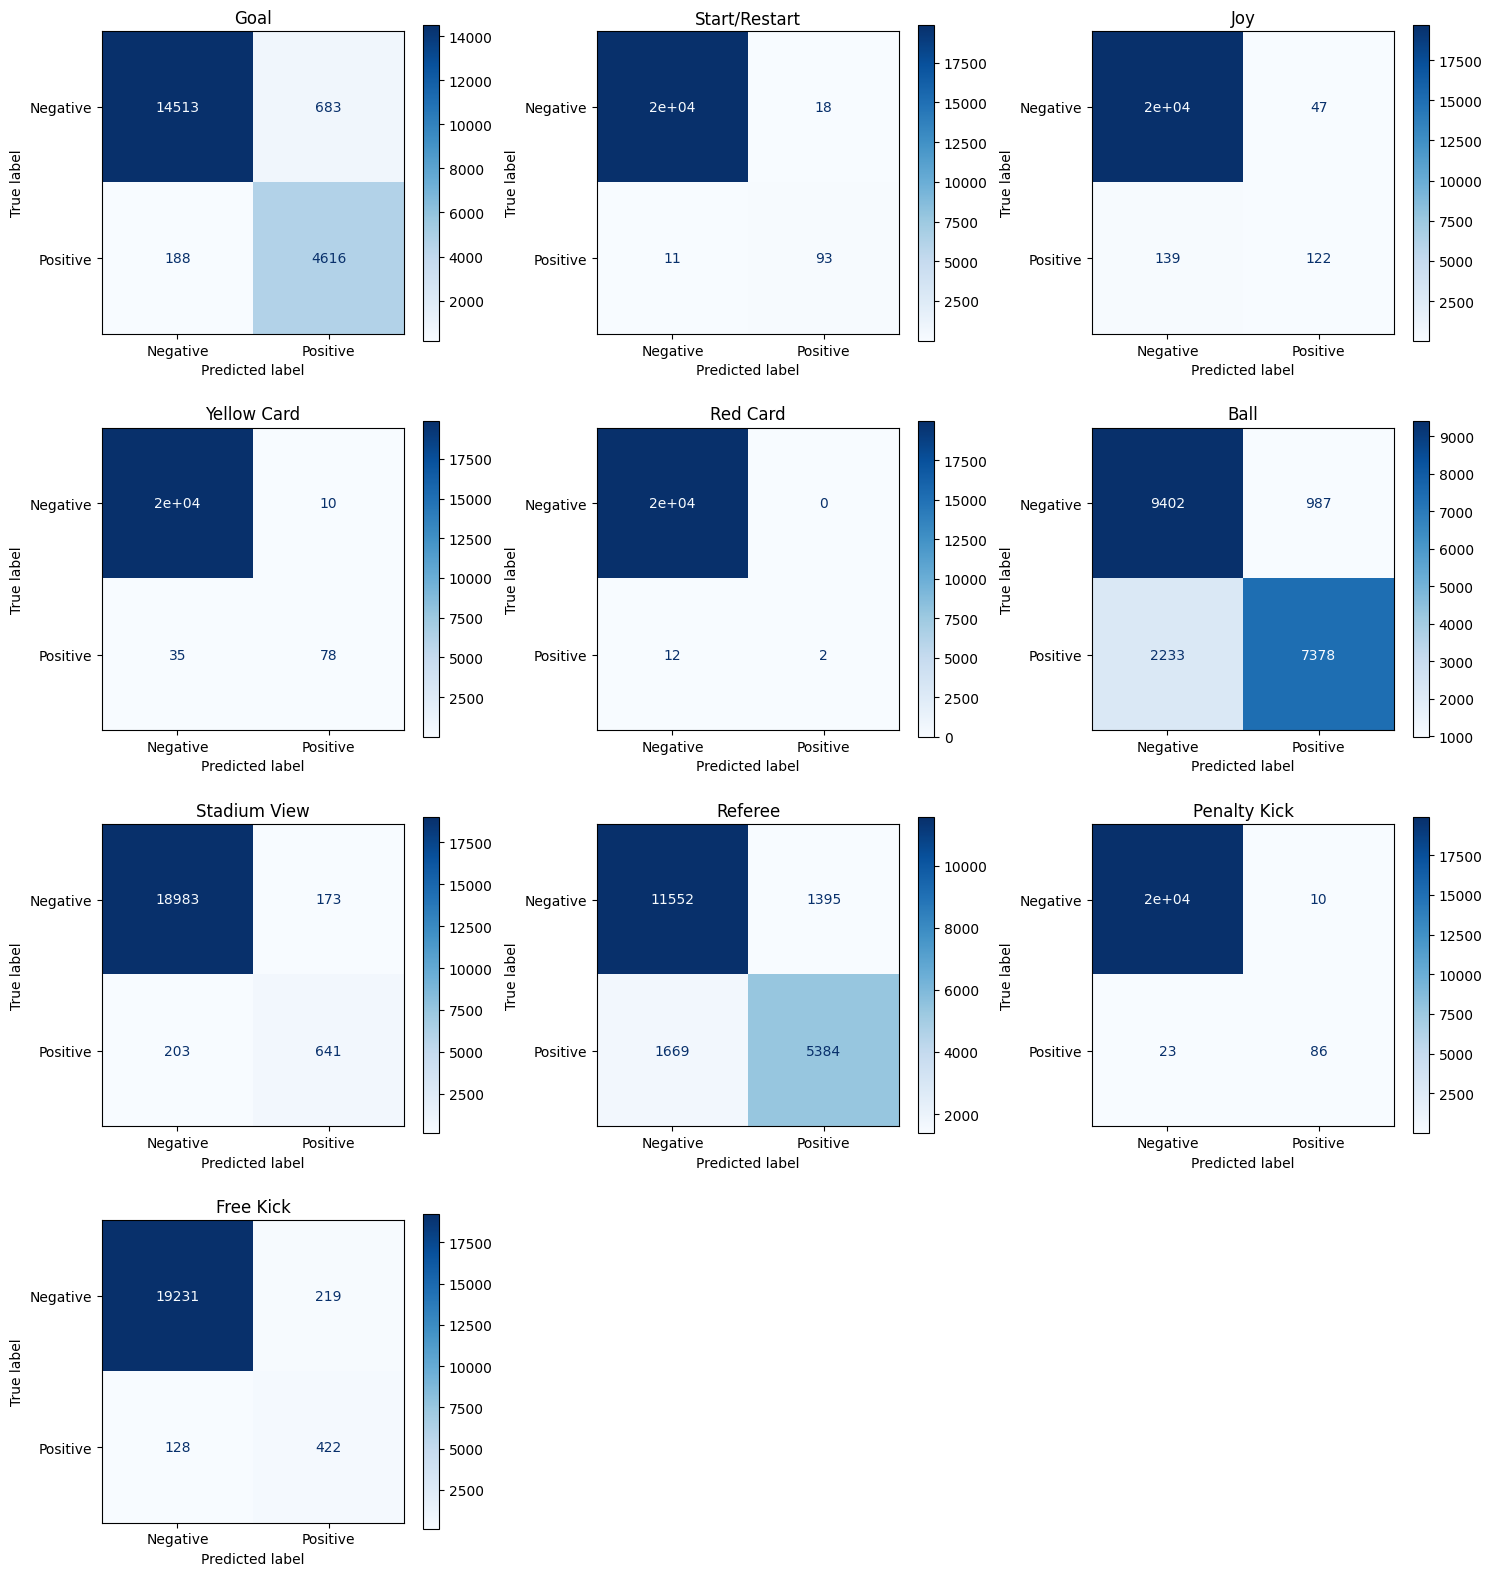

In [14]:
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def per_class_accuracy_from_loader(model, loader, label_names, device='cuda:0', threshold=0.5):
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    all_true = []
    all_pred = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= threshold).astype(int)
            all_pred.append(preds)
            all_true.append(labels.numpy().astype(int))
    y_pred = np.vstack(all_pred)
    y_true = np.vstack(all_true)
    n_samples = y_true.shape[0]
    accs = ((y_pred == y_true).sum(axis=0) / n_samples) * 100.0
    # print results
    for i, name in enumerate(label_names):
        positives = int(y_true[:, i].sum())
        print(f"{name}: accuracy={accs[i]:.2f}%  (positives={positives}/{n_samples})")

    # For multilabel data, compute confusion matrix per label
    n_labels = y_true.shape[1]
    n_cols = min(3, n_labels)  # display up to 3 CMs per row
    n_rows = (n_labels + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_labels == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i in range(n_labels):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i], labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
        disp.plot(cmap=plt.cm.Blues, ax=axes[i])
        axes[i].set_title(f'{label_names[i]}', fontsize=12)
        
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0, digits=4))
    
    # hide unused subplots
    for j in range(n_labels, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    return accs, y_true, y_pred

# Example: build the same validation loader used for training and compute per-class accuracy
# Adjust batch_size, val_frac and device as needed
batch_size = 32
val_frac = 0.2
device = 'cuda:0'     # or 'cpu'

# recreate dataset and split (must match how you split during training)
val_transform = transforms.Compose([
    transforms.Resize((px, px)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
ds_full = MultiLabelImageDatasetBinary(csv_file, img_dir=img_base_dir, transform=val_transform, path_col=path_col)
n = len(ds_full)
indices = list(range(n))
_, val_idx = train_test_split(indices, test_size=val_frac, random_state=0, shuffle=True)
val_set = Subset(ds_full, val_idx)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

accs, y_true, y_pred = per_class_accuracy_from_loader(model, val_loader, ds_full.label_cols, device=device, threshold=0.5)
